# Home Credit Default Risk

Задача — по текущей заявке и кредитной истории предсказать платёжные затруднения клиента.
В этом ноутбуке последовательно разобраны данные, подготовка признаков, выбор моделей
и результаты экспериментов. Таблицы и графики построены по сохранённым результатам.
Код подготовки и обучения находится в ноутбуках 01–03.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd()
if not (ROOT / "reports/metrics").exists():
    ROOT = ROOT.parent
M = ROOT / "reports/metrics"
F = ROOT / "reports/figures"
summary = json.loads((M / "run_summary.json").read_text())
data = json.loads((M / "data_summary.json").read_text())
official = json.loads((M / "submission_status.json").read_text())
assert json.loads((M / "verification.json").read_text())["passed"]

## 1. Что находится в данных

Основная таблица содержит анкету, доход, параметры текущего кредита и внешние рейтинги.
К ней относятся несколько таблиц истории:

| Таблица | Содержание |
|---|---|
| application_train/test | Текущая заявка |
| previous_application | Предыдущие заявки и условия договоров |
| bureau, bureau_balance | Кредиты в бюро и их месячная история |
| POS_CASH_balance, credit_card_balance | Месячные остатки и состояния счетов |
| installments_payments | Выплаты по взносам |

У одного клиента может быть несколько договоров, а у договора — много записей по месяцам
и платежам. Ниже приведены размеры таблиц, использованных при построении признаков.

In [2]:
display(pd.DataFrame([
    {"выборка": "обучение", "заявок": data["train_rows"]},
    {"выборка": "тест", "заявок": data["test_rows"]},
]))
print(f"TARGET = 1: {data['target_positive']:,} клиентов ({data['target_positive']/data['train_rows']:.2%})")
display(pd.read_csv(M / "table_audit.csv"))

,выборка,заявок
0,обучение,307511
1,тест,48744


TARGET = 1: 24,825 клиентов (8.07%)


,table,rows,columns
0,bureau,1716428,17
1,bureau_balance,24179741,3
2,previous_application,1670214,37
3,POS_CASH_balance,10001358,8
4,credit_card_balance,3840312,23
5,installments_payments,13605401,8


Положительных примеров около 8%. Для оценки используется заданная соревнованием
метрика ROC AUC: она показывает, насколько хорошо модель ранжирует клиентов по риску.
Порог классификации для отправки не требуется — в файл записываются вероятности.

## 2. Подготовка и исходные признаки

История сначала агрегировалась по договору или взносу, затем по клиенту. Так суммы
из разных таблиц можно присоединить к анкете без размножения её строк.

Специальное значение даты 365243 заменялось на пропуск. Для отсутствующей истории
добавлялся индикатор. В суммах выплат учитывались только платежи к дате текущей заявки.

Отдельная обработка нужна для частичной оплаты: обязательство на 100 может быть
погашено выплатами 40 и 60. Для определения просрочки учитывалась дата, когда
накопленная сумма достигала 100. Неизвестная дата или сумма оставляла статус
недоплаты неопределённым. Противоречивые записи одного взноса исключались из его
агрегатов; клиент оставался в выборке.

Получилось 1250 признаков: суммы и доли задолженности, просрочки, использование
лимитов, статистики прошлых заявок, последние наблюдения и изменения во времени.
Массовое удаление клиентов с пропусками и балансировка синтетическими строками
не применялись.

## 3. Как сравнивались модели

Из обучающих данных выделены 246 009 клиентов для разработки и 61 502 для итоговой
проверки. При первом сравнении внутри development использовалась одна и та же
валидация из 49 202 клиентов. После отбора моделей проводились пять фолдов
кросс-валидации, затем оценка отложенной части.

Сначала сравнивались LightGBM, XGBoost и CatBoost. Все три модели строят ансамбли
деревьев, но отличаются способом построения и обработкой категорий.
У XGBoost проверялась глубина деревьев, у LightGBM — параметры гистограмм и листьев.
CatBoost также рассматривался как возможная добавка к другой модели.

### Первые результаты

In [3]:
initial = pd.read_csv(M / "initial_benchmark.csv")
tuning = pd.read_csv(M / "tuning_benchmark.csv")
first_stage = pd.concat([initial, tuning], ignore_index=True).sort_values("auc", ascending=False)
display(first_stage[["name", "auc", "fit_seconds", "iterations"]].round(6))

,name,auc,fit_seconds,iterations
0,xgb_gpu_depth7,0.791639,112.824370,934
1,xgb_gpu_depth5,0.790959,100.180987,1149
6,lgb_gpu_127_slow,0.790472,157.885085,1104
7,lgb_gpu_127_leaves47,0.790444,145.364463,806
8,lgb_gpu_255,0.790055,155.699913,719
2,lgb_cpu_baseline,0.789813,326.076799,738
3,lgb_gpu_63,0.789112,103.470242,822
4,cat_gpu_depth6,0.788540,226.991285,3613
5,cat_gpu_depth8,0.787137,212.233704,1906


На исходных признаках лучший одиночный AUC получил XGBoost глубины 7 — 0.791639.
CatBoost глубины 6 получил 0.788540; увеличение глубины до 8 в этом запуске не помогло.
Лучший проверенный вариант LightGBM получил 0.790472.

Следующим шагом стало расширение признаков. Время обучения учитывалось при выборе
числа экспериментов; расчёты выполнялись на Kaggle GPU.

## 4. Какие признаки добавлялись и зачем

Сумма кредита описывает только часть нагрузки. Дополнительно рассчитывались
отношение кредита к аннуитету, общая плановая выплата и её отношение к кредиту.
Разность плановых и наблюдённых выплат использовалась как приближение оставшихся
обязательств.

Для последних 90 и 730 дней строились отдельные агрегаты. Также добавлялись
характеристики последнего договора и отдельных типов кредитов. Это позволяло
модели учитывать недавние изменения, которые могут теряться в среднем за всю историю.

Эти признаки вместе с дополнениями к анкете дали 302 новых столбца.

Ещё 40 столбцов — сравнения с похожими клиентами: разности и отношения дохода,
кредита, аннуитета и внешних рейтингов к медианам группы. Группы задавались
профессией, образованием, организацией и другими полями. Медианы считались только
на обучающей части фолда; для редких групп использовалась общая train-медиана.

### Проверка на прежней модели

In [4]:
benchmark = pd.read_csv(M / "benchmark.csv").set_index("name")
feature_comparison = benchmark.loc[
    ["xgb_gpu_depth7", "xgb_aug_depth7", "xgb_peer_depth7"], ["features", "auc"]
].copy()
feature_comparison["изменение AUC"] = feature_comparison.auc - feature_comparison.auc.iloc[0]
display(feature_comparison.round(6))

,features,auc,изменение AUC
name,,,
xgb_gpu_depth7,original,0.791639,0.000000
xgb_aug_depth7,augmented,0.791824,0.000185
xgb_peer_depth7,peer,0.791301,-0.000338


При прежних параметрах добавление 302 признаков повысило AUC на 0.000185.
После добавления сравнений с группами AUC снизился. Заметного улучшения на этом
варианте XGBoost не получилось.

## 5. Изменение параметров

На расширенной таблице проверялся XGBoost с глубиной 4 и меньшей долей признаков
на дерево. Такая настройка ограничивает сложность взаимодействий и число полей,
доступных каждому дереву. Одновременно менялись ещё несколько параметров.
Их значения показаны ниже.

,исходный XGBoost,выбранный XGBoost
max_depth,7.00,4.000
min_child_weight,50.00,30.000
learning_rate,0.03,0.035
colsample_bytree,0.85,0.500
max_bin,128.00,256.000
subsample,0.85,0.850
reg_alpha,0.50,0.500
reg_lambda,15.00,15.000


,features,auc,fit_seconds
name,,,
xgb_peer_depth4,peer,0.792257,147.625124
xgb_aug_depth7,augmented,0.791824,136.708543
xgb_gpu_depth7,original,0.791639,112.824370
lgb_peer_gbdt,peer,0.791493,313.646111
xgb_peer_depth7,peer,0.791301,128.665671
lgb_peer_goss,peer,0.790649,367.305526
lgb_gpu_127_slow,original,0.790472,157.885085
cat_gpu_depth6,original,0.788540,226.991285


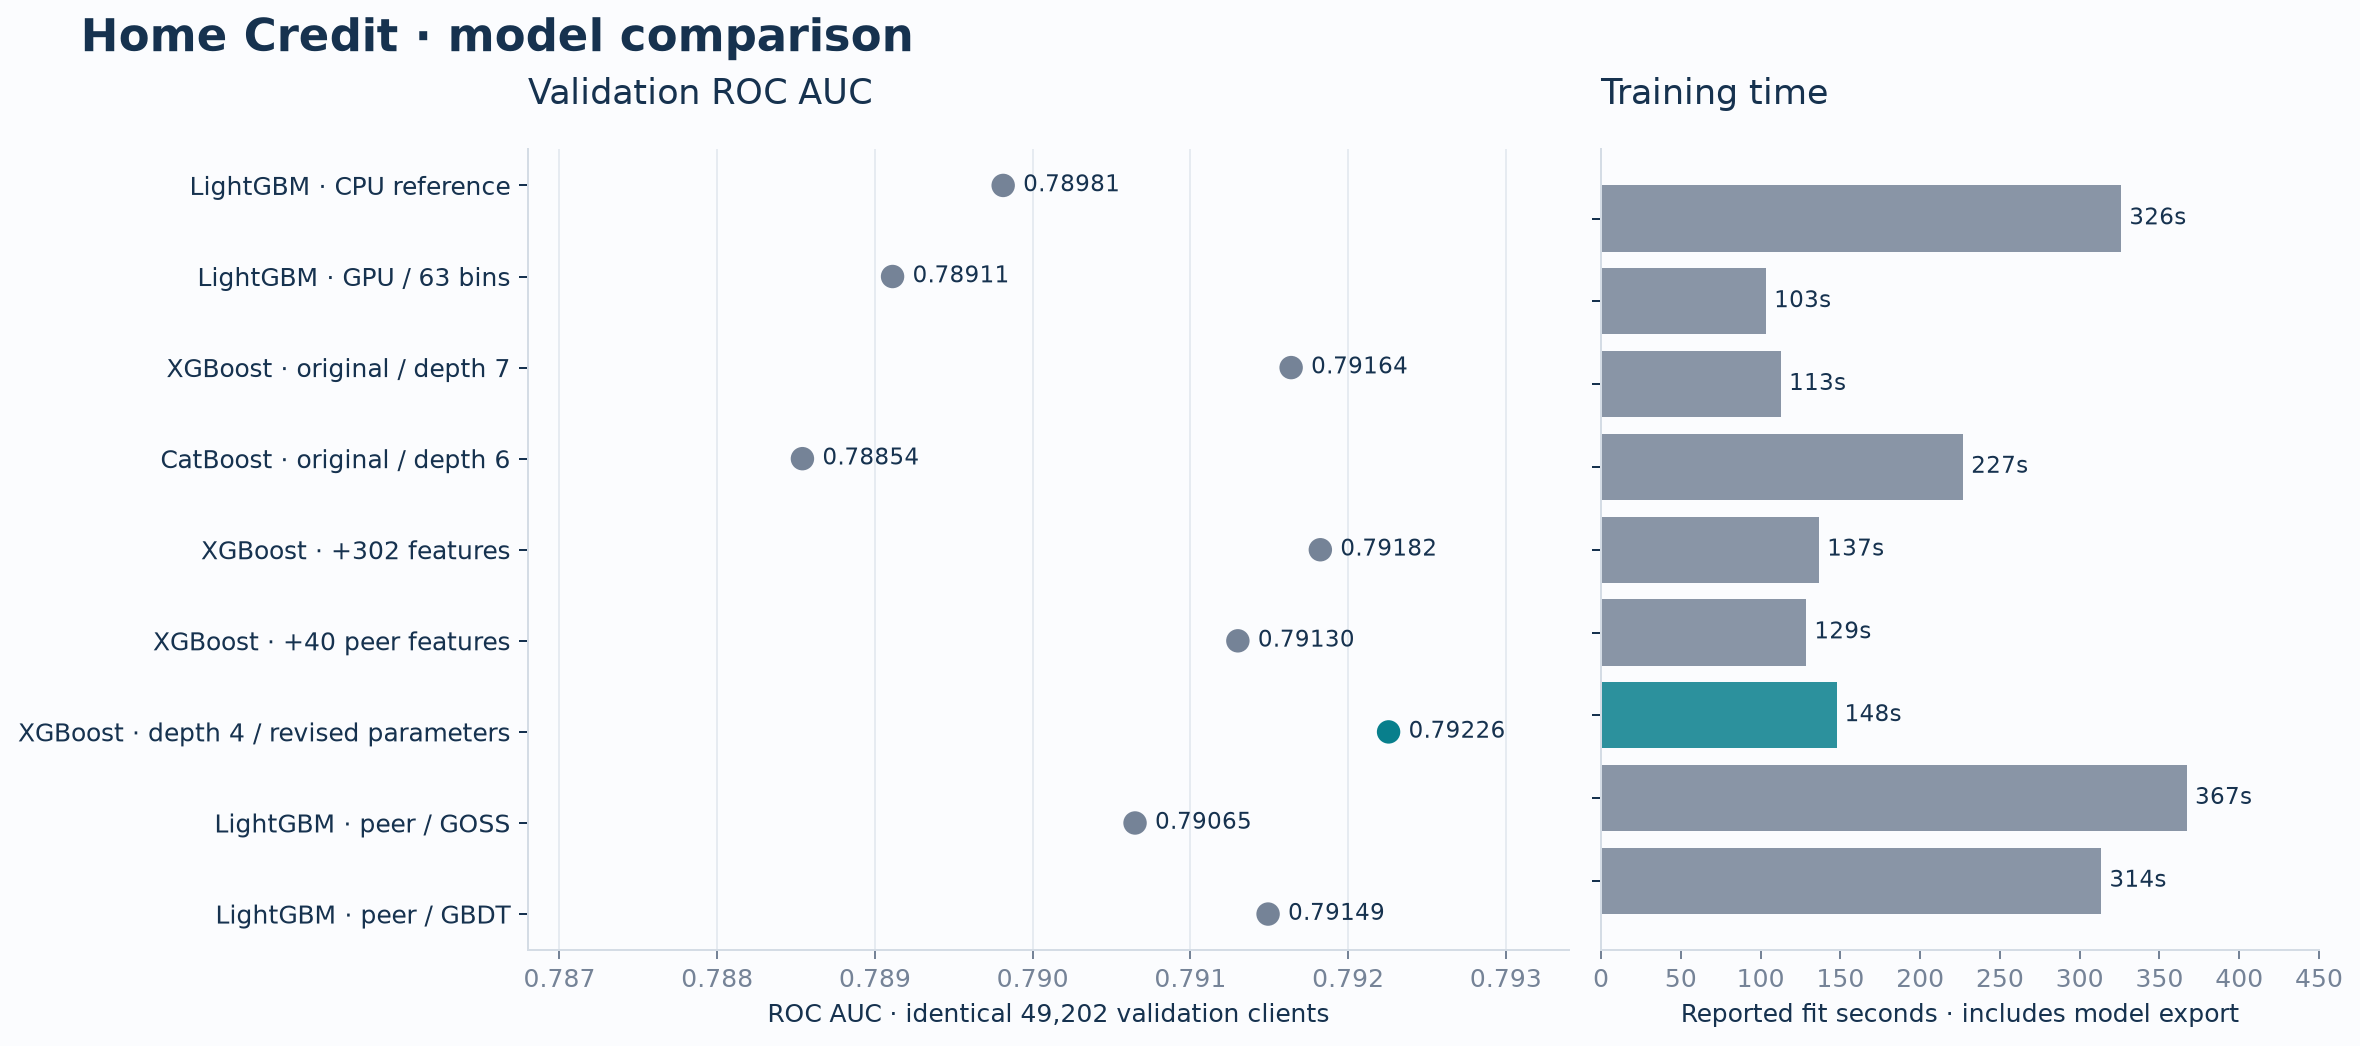

In [5]:
initial_specs = json.loads((M / "initial_benchmark_specs.json").read_text())
old_xgb = next(s["params"] for s in initial_specs if s["name"] == "xgb_gpu_depth7")
new_xgb = next(s["params"] for s in summary["selected_specs"] if s["kind"] == "xgb")
parameters = ["max_depth", "min_child_weight", "learning_rate", "colsample_bytree",
              "max_bin", "subsample", "reg_alpha", "reg_lambda"]
display(pd.DataFrame({
    "исходный XGBoost": {p: old_xgb[p] for p in parameters},
    "выбранный XGBoost": {p: new_xgb[p] for p in parameters},
}))
display(benchmark[["features", "auc", "fit_seconds"]].sort_values("auc", ascending=False).round(6))
display(Image(filename=str(F / "benchmark.png")))

Лучший результат среди этих запусков — 0.792257 — дал XGBoost глубины 4.
LightGBM GBDT и GOSS на расширенных признаках получили 0.791493 и 0.790649.

Поскольку менялось несколько параметров, результат относится ко всей конфигурации.
Контрольная версия depth 4 на исходных 1250 признаках не запускалась. Она потребовалась
бы для отдельной оценки пользы новых признаков.

## 6. Смешивание моделей

На первоначальном сравнении смесь 75% XGBoost depth 7 и 25% CatBoost дала AUC 0.792511.
После замены XGBoost на вариант depth 4 смесь получила 0.793073 на тех же клиентах.
Эти две модели были выбраны для пятифолдовой проверки.

Для каждого клиента development сохранён прогноз модели, которая не обучалась
на его строке. Эти прогнозы называются out-of-fold (OOF). По ним сравнивались
одиночные модели и смеси 25/75, 50/50 и 75/25.

In [6]:
frozen = json.loads((M / "frozen_selection.json").read_text())
blends = pd.DataFrame([
    {"доля XGBoost": r["weights"].get("xgb_peer_depth4", 0),
     "доля CatBoost": r["weights"].get("cat_gpu_depth6", 0),
     "OOF AUC": r["auc"]}
    for r in frozen["comparisons"]
])
display(blends.round(6))
display(pd.read_csv(M / "fold_summary.csv").round(6))

,доля XGBoost,доля CatBoost,OOF AUC
0,0.75,0.25,0.798207
1,0.50,0.50,0.797934
2,1.00,0.00,0.797366
3,0.25,0.75,0.796563
4,0.00,1.00,0.793976


,fold,n,positives,auc_blend
0,0,49202,3972,0.791495
1,1,49202,3972,0.804617
2,2,49202,3972,0.798243
3,3,49202,3972,0.797272
4,4,49201,3972,0.799540


На пяти фолдах смесь 75/25 получила 0.798207 против 0.797366 у XGBoost.
Этот вариант выбран для финальной проверки. Значения OOF и первоначальной
валидации относятся к разным наборам клиентов; их разность не является
приростом от ансамбля.

## 7. Отложенная выборка

После выбора весов ансамбль оценён на 61 502 отложенном клиенте.

,выборка,auc,ap,logloss
0,development OOF,0.798207,0.298229,0.233054
1,holdout,0.798087,0.294200,0.233474


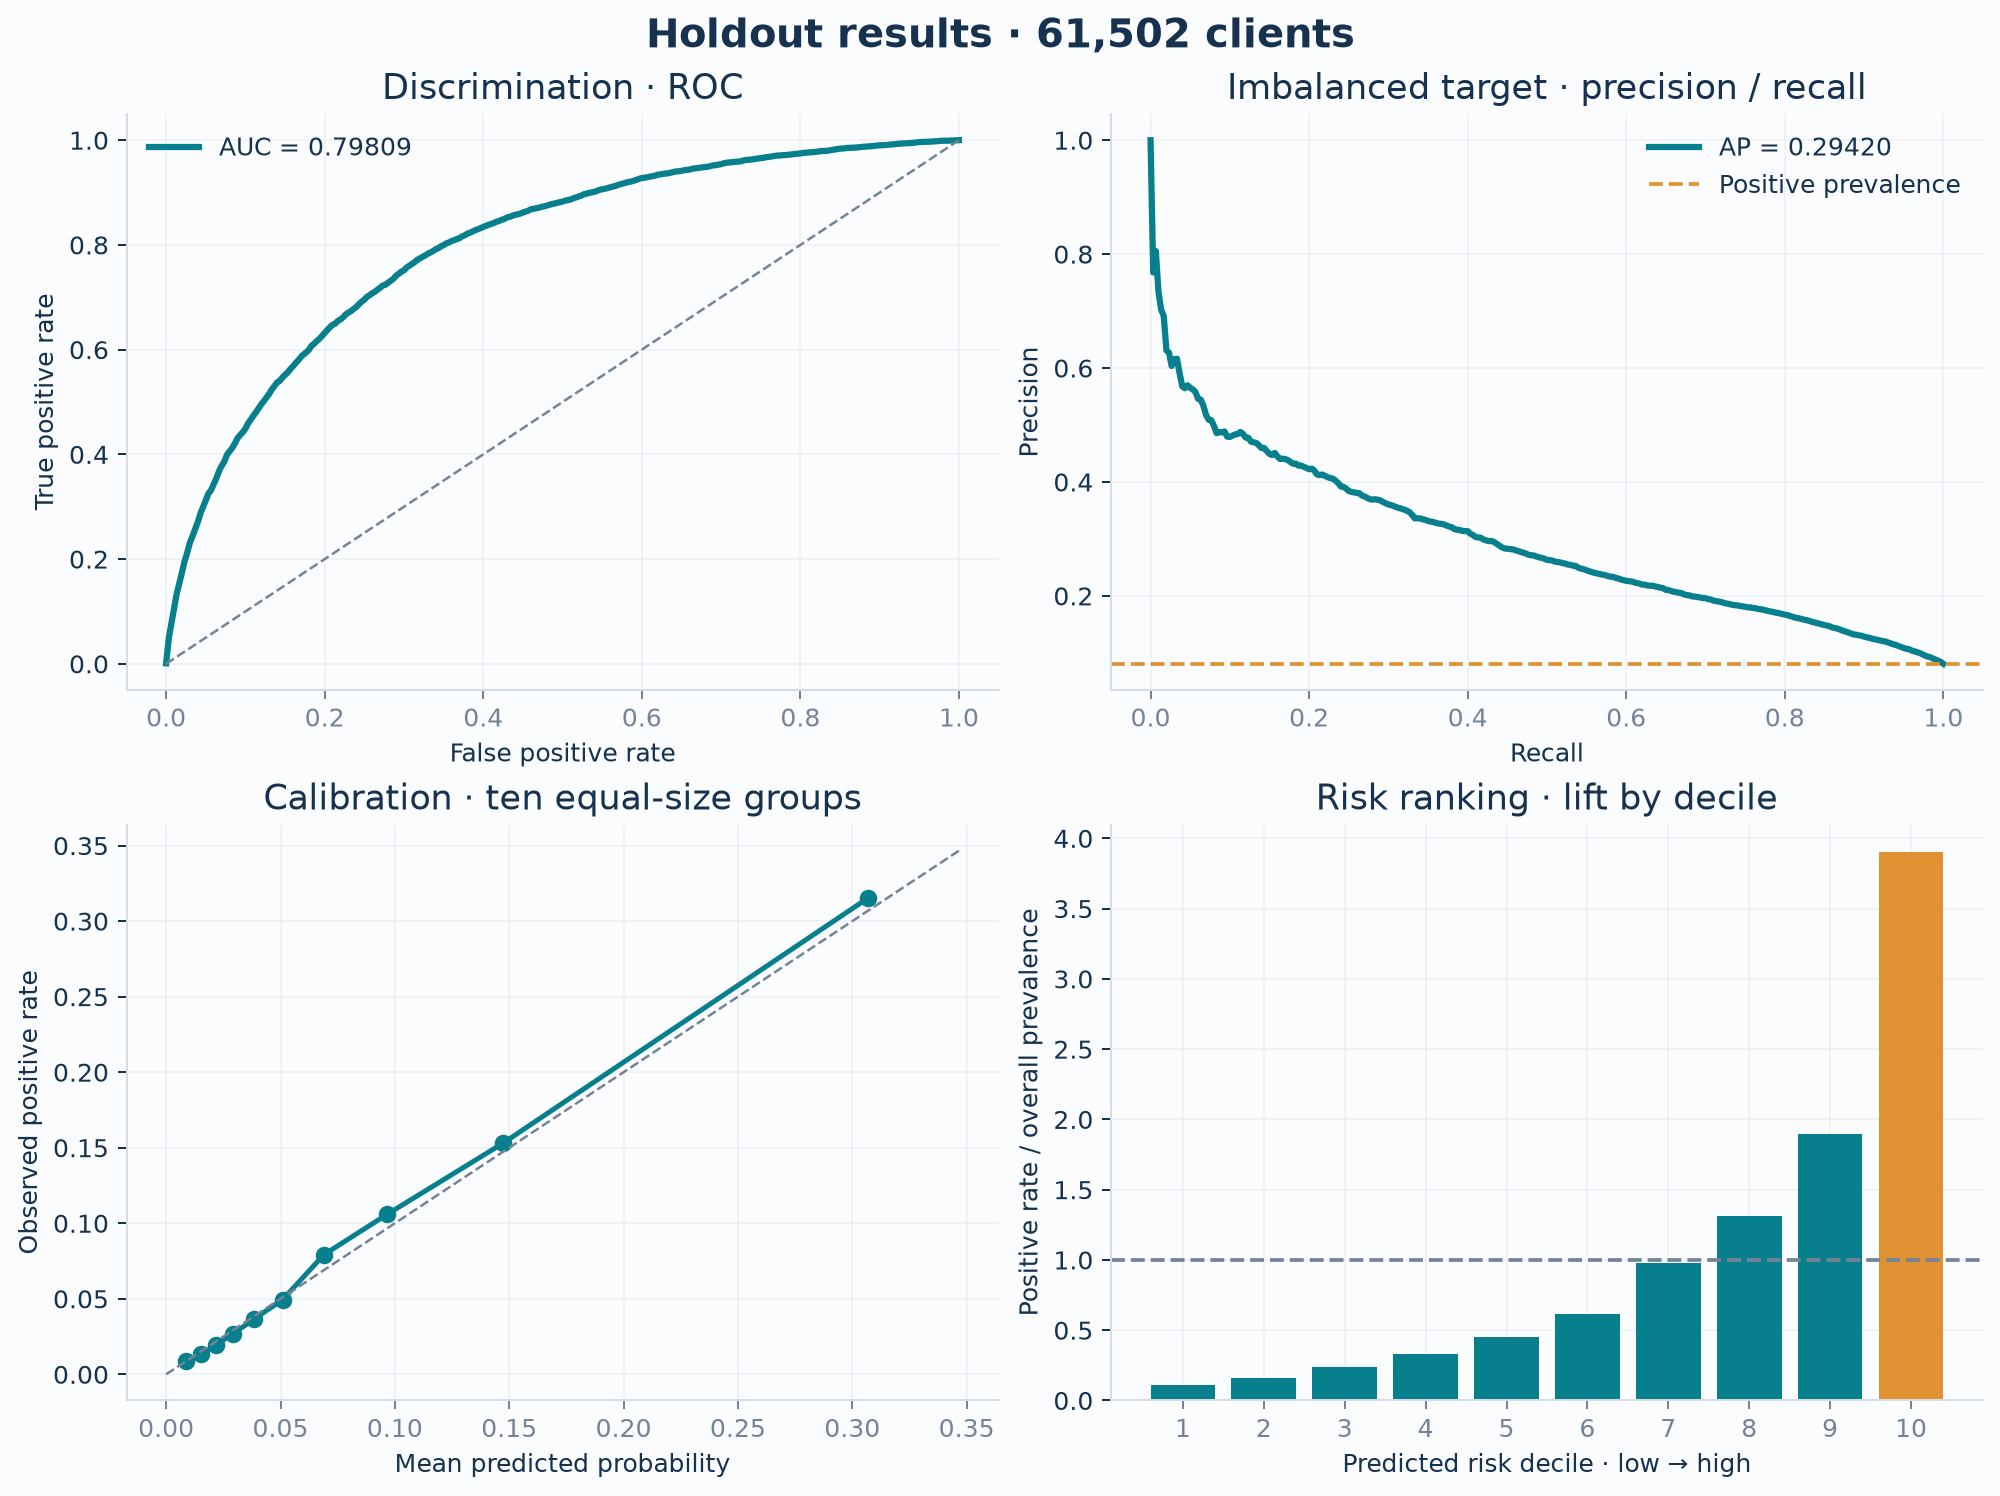

В 10% заявок с самым высоким прогнозом доля TARGET=1: 31.51%
Во всём holdout: 8.07%


In [7]:
display(pd.DataFrame([
    {"выборка": "development OOF", **summary["oof"]},
    {"выборка": "holdout", **{k: summary["holdout"][k] for k in ["auc", "ap", "logloss"]}}
]).round(6))
display(Image(filename=str(F / "holdout.png")))
cal = pd.read_csv(M / "holdout_calibration.csv")
print(f"В 10% заявок с самым высоким прогнозом доля TARGET=1: {cal.iloc[-1]['observed_rate']:.2%}")
print(f"Во всём holdout: {data['holdout_prevalence']:.2%}")

Holdout AUC составил 0.798087 и оказался близок к OOF.
По результатам этой проверки параметры и веса не менялись.

### Какие признаки использовали финальные модели

Среди наиболее важных признаков обеих моделей находятся внешние рейтинги и их
производные. У XGBoost в верхней части списка присутствует также новый признак
сроков одобренных кредитов. График показывает встроенную важность;
шкалы XGBoost и CatBoost различаются.

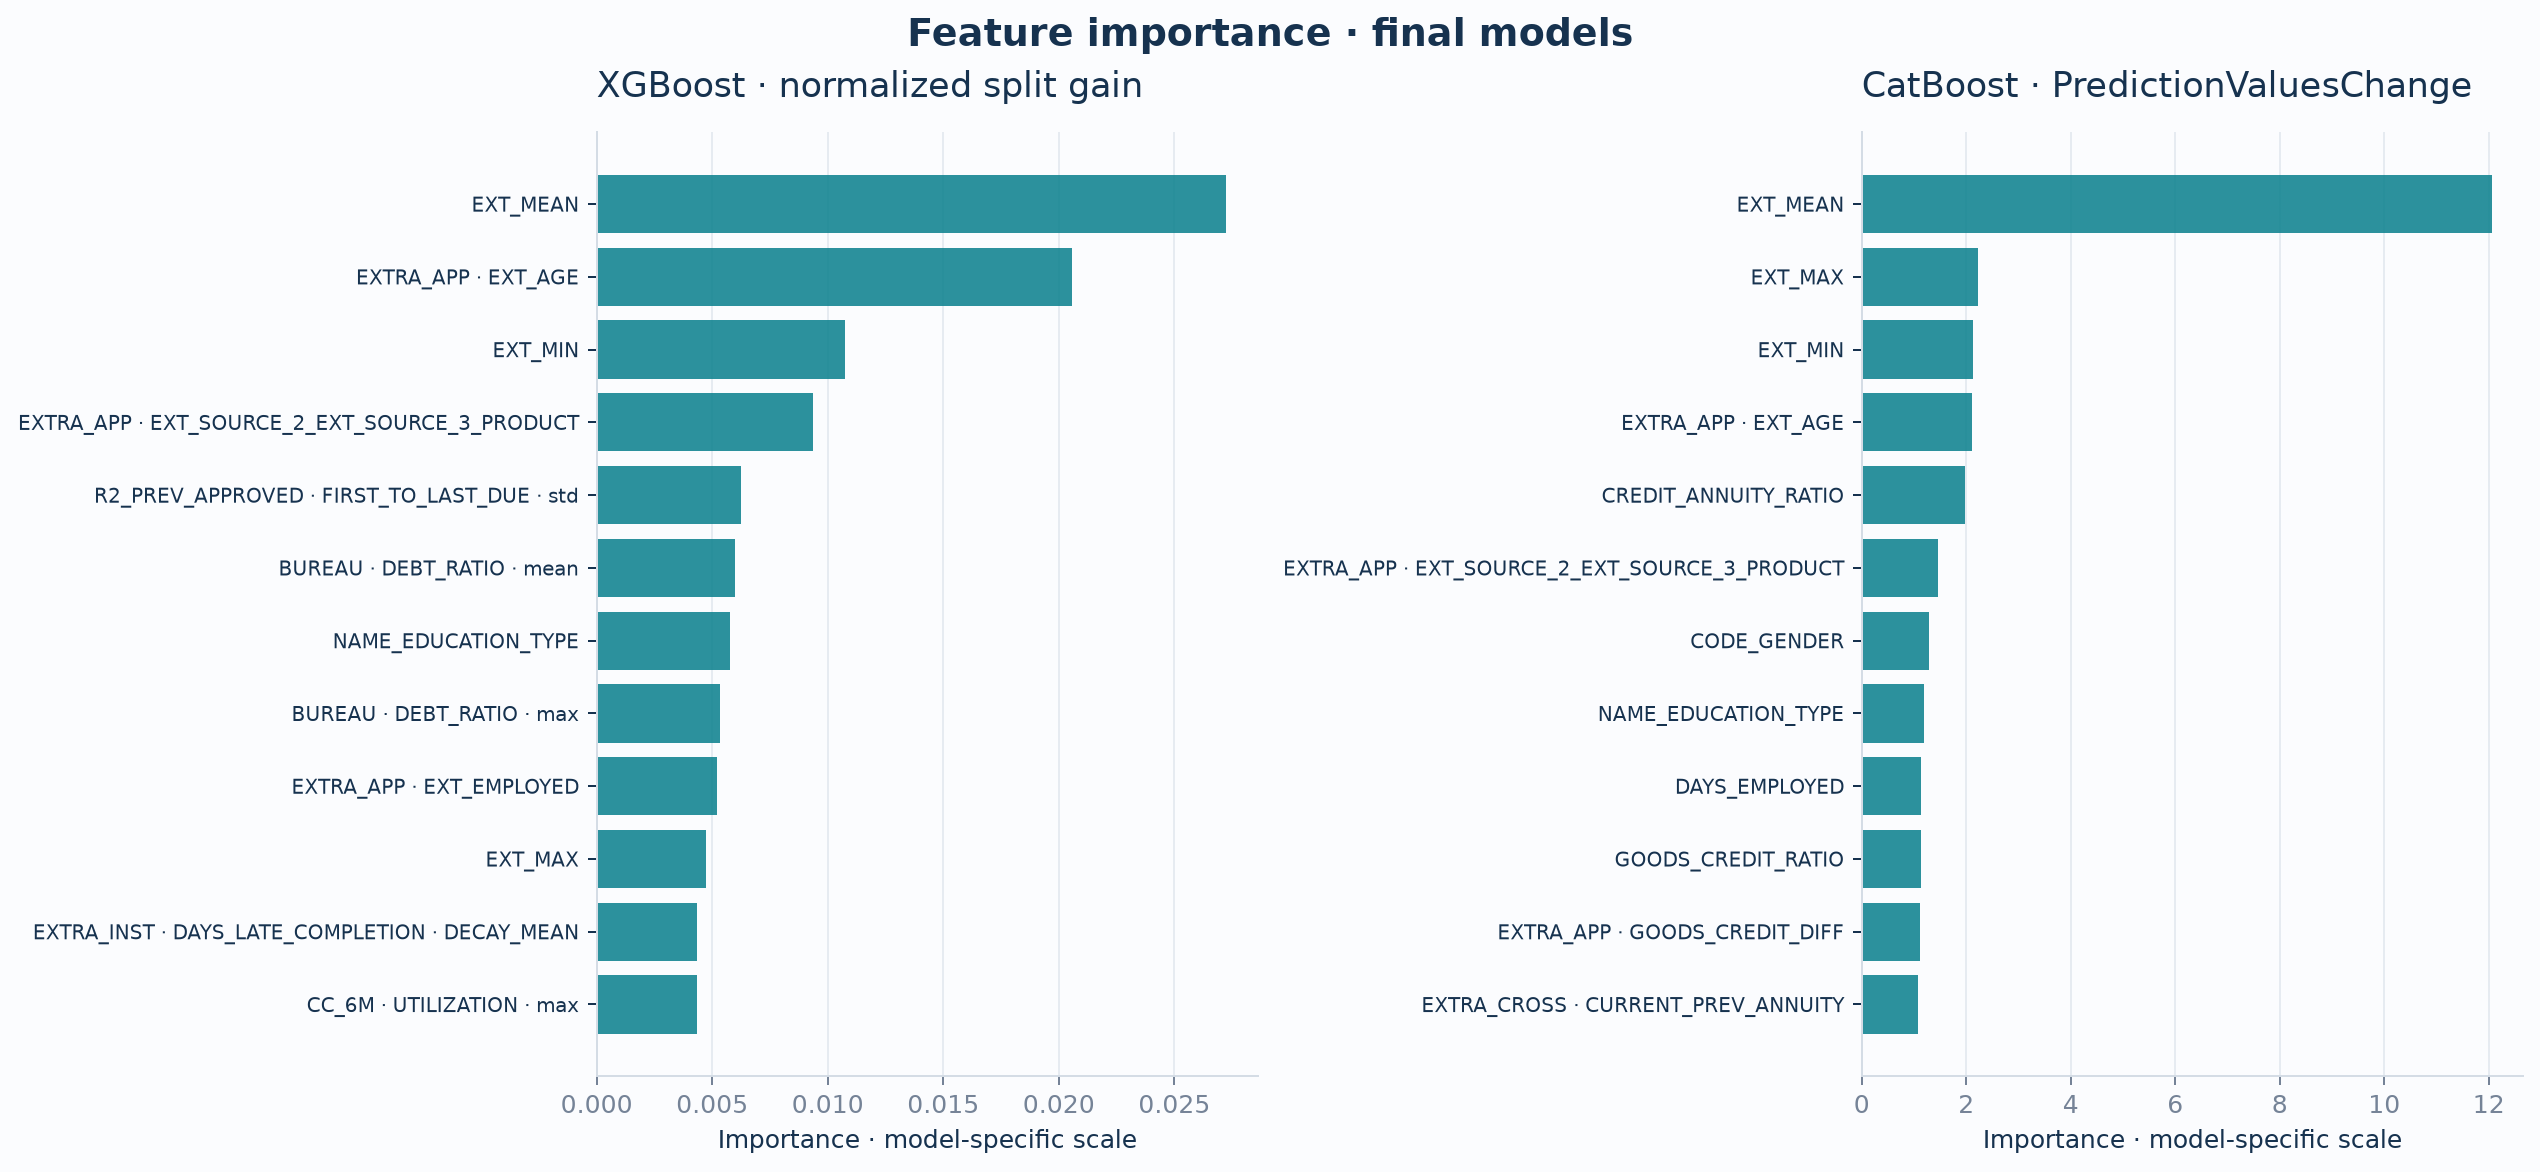

In [8]:
display(Image(filename=str(F / "feature_importance.png")))

## 8. Финальное обучение и Kaggle

Для отправки модели обучены на всех 307 511 метках с seed 42 и 142.
Количество деревьев взято как медиана остановок на фолдах: 1500 для XGBoost,
3284 для CatBoost. Прогнозы усреднены по seed, затем объединены в смесь 75/25.

В Kaggle выполнена одна поздняя отправка в завершённое соревнование.

In [9]:
display(pd.DataFrame([{
    "submission": official["submission_ref"], "статус": official["status"],
    "public AUC": official["public_score"], "private AUC": official["private_score"],
    "последний запуск, мин": round(summary["seconds"] / 60, 1),
}]))

,submission,статус,public AUC,private AUC,"последний запуск, мин"
0,56605291,COMPLETE,0.80088,0.79968,51.0


## 9. Выводы

Лучший из проверенных вариантов — XGBoost на 1592 признаках и CatBoost на исходных
1250, объединённые с весами 75/25. Итоговый private AUC — 0.79968.

Добавление признаков при прежних параметрах дало небольшой прирост. Изменение
параметров XGBoost и смешивание с CatBoost улучшили результаты выполненных сравнений.
Чтобы решить, оправдано ли усложнение признаков, стоит отдельно сравнить depth 4
на исходной и расширенной таблицах при одинаковых настройках.

### Неопределённость небольших различий

После обучения выполнено парное сравнение прогнозов с помощью bootstrap.
Обе модели сравниваются на одних и тех же повторно выбранных клиентах.

,model,reference,delta_auc,ci95
0,xgb_aug_depth7,original XGB depth 7,0.000185,"[-0.0014793714636103321, 0.0019293691563918155]"
1,xgb_peer_depth7,original XGB depth 7,-0.000338,"[-0.001893562810555996, 0.0014527883555438825]"
2,xgb_peer_depth4,original XGB depth 7,0.000618,"[-0.0009391332128346724, 0.0022640592259902557]"
3,new_selected_blend,previous 75/25 blend,0.000562,"[-0.0006064299532946516, 0.001835014151681591]"


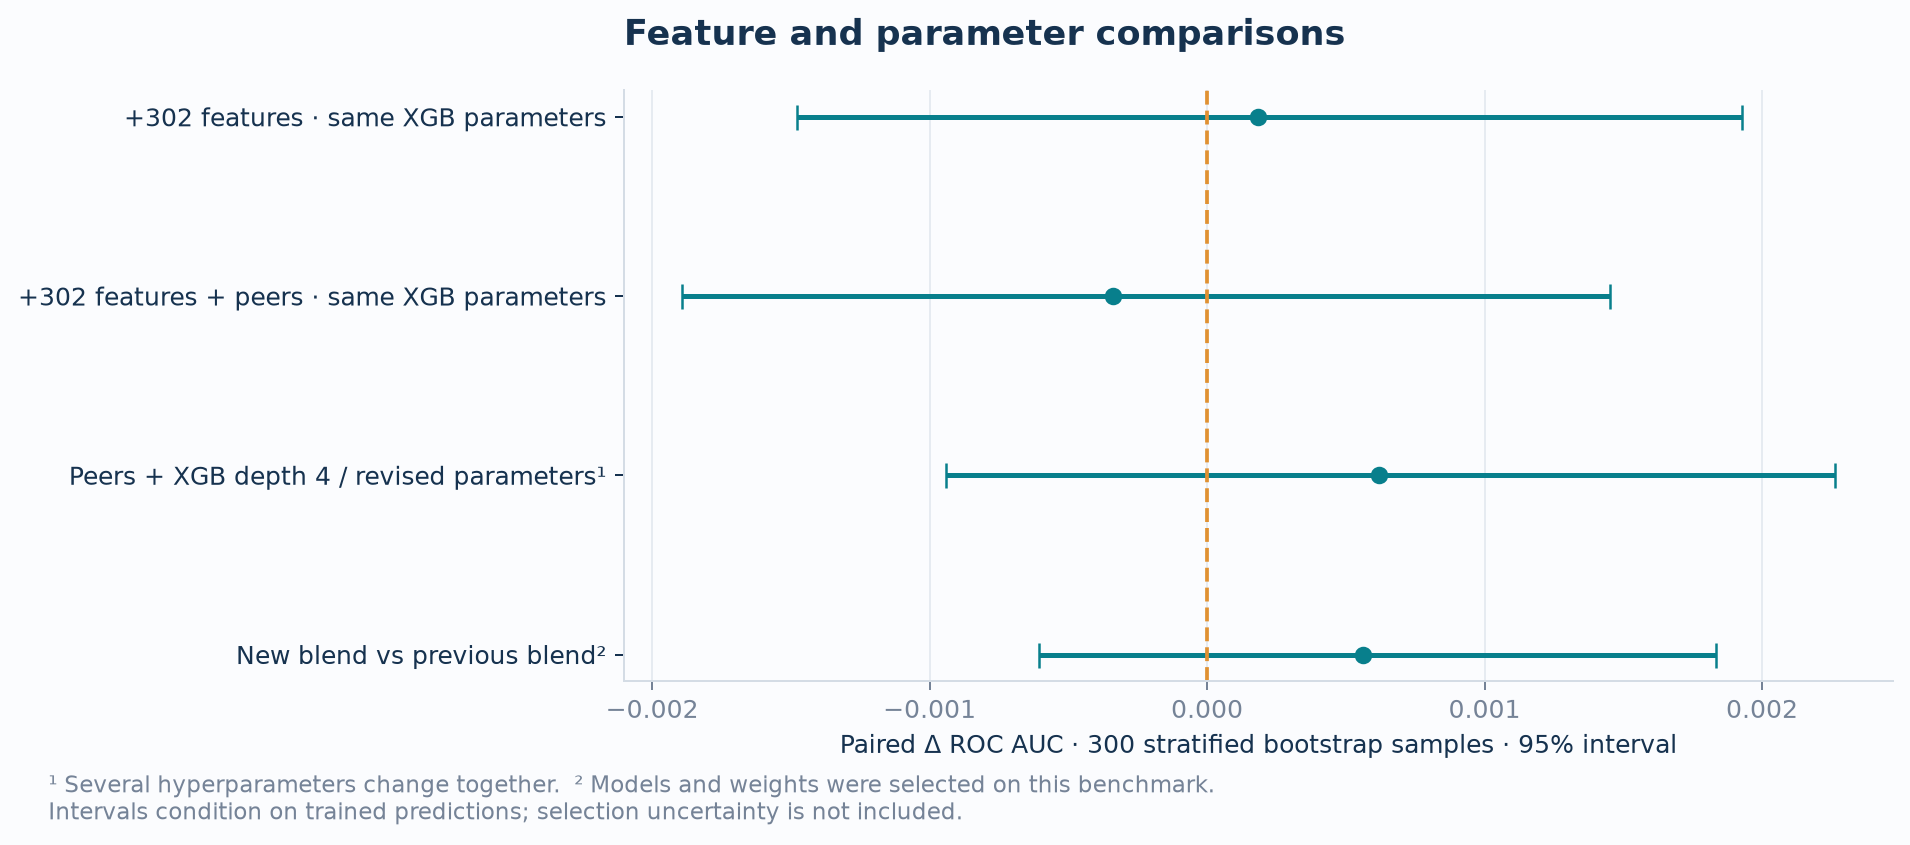

In [10]:
paired = pd.DataFrame(json.loads((M / "paired_feature_comparison.json").read_text()))
display(paired)
display(Image(filename=str(F / "ablation.png")))

Интервалы прироста включают ноль. Небольшое преимущество выбранной конфигурации
может измениться при другом разбиении или повторном обучении.

OOF рассчитан после предварительного отбора конфигураций, поэтому оценка может быть
оптимистичной. Ранняя история использования исходного holdout полностью не восстановлена.
Сохранённые результаты позволяют проверить метрики, но не заменяют повторных экспериментов.

[Подробное описание](../docs/RESEARCH.md) · [Порядок запуска](../docs/REPRODUCIBILITY.md)